In [1]:
import pandas as pd

Rolling aggregations let you perform calculations on shifting periods of time
- This can be used to callculate things like moving averages, which are helpful in reducing noise when plotting trends

In [2]:
retail = pd.read_csv("../retailFiles/retail_2016_2017.csv", parse_dates=["date"])
retail.head()

,id,date,store_nbr,family,sales,onpromotion
0,1945944,2016-01-01,1,AUTOMOTIVE,0.0,0
1,1945945,2016-01-01,1,BABY CARE,0.0,0
2,1945946,2016-01-01,1,BEAUTY,0.0,0
3,1945947,2016-01-01,1,BEVERAGES,0.0,0
4,1945948,2016-01-01,1,BOOKS,0.0,0


In [6]:
retail_daily = retail.set_index("date").loc[:, "sales"].resample("D").sum().round(2)
retail_daily.head()

date
2016-01-01      16433.39
2016-01-02    1066677.42
2016-01-03    1226735.72
2016-01-04     955956.88
2016-01-05     835320.44
Freq: D, Name: sales, dtype: float64

In [8]:
retail_daily.rolling(2).mean().head() # Rolling windows of 2
# in SQL:
# AVG(retail_daily) OVER (ORDER BY date_column ROWS BETWEEN 1 PRECEDING AND CURRENT ROW) AS rolling_avg_2_days

date
2016-01-01            NaN
2016-01-02     541555.405
2016-01-03    1146706.570
2016-01-04    1091346.300
2016-01-05     895638.660
Freq: D, Name: sales, dtype: float64

<Axes: xlabel='date'>

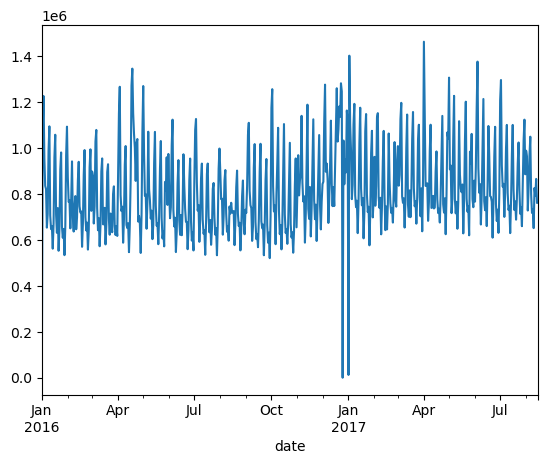

In [9]:
retail_daily.plot()

<Axes: xlabel='date'>

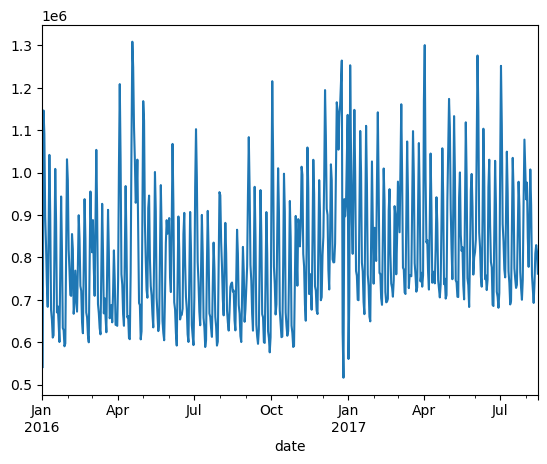

In [10]:
retail_daily.rolling(2).mean().plot()

<Axes: xlabel='date'>

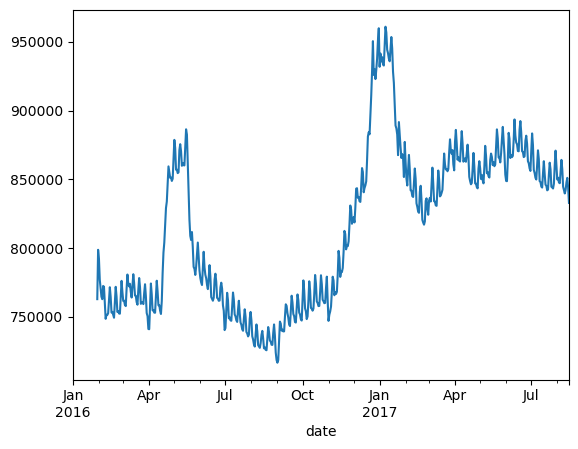

In [11]:
retail_daily.rolling(30).mean().plot()